# Active transcription on a higher-power dataset (GA vs. Ctrl)

The same `active_score` workflow as {doc}`t_ec_active_transcription`, run on a
better-powered mouse dataset — a side-by-side reference for what the output
looks like when cells-per-replicate is no longer the bottleneck.

```{admonition} 📋 At a glance
:class: note

Dataset
: `GA_test.h5ad` — bundled mouse scRNA-seq test data with `spliced` /
  `unspliced` layers and group-qualified individual labels
  (`GA_Ind1..3` / `Ctrl_Ind1..3`). Derived from Li et al. (2026),
  *Advanced Science* (DOI [10.1002/advs.75389](https://doi.org/10.1002/advs.75389));
  GEO [GSE266598](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE266598)
  (see {doc}`../references`).

Design
: **GA vs. Ctrl**, 3 individuals per group, but ~330 cells per individual —
  roughly 10× the per-replicate depth of the EC dataset.

You'll learn
: how the identical pseudobulk + PyDESeq2 `active_score` pipeline behaves when
  the same 3-vs-3 replicate structure carries real statistical power.

Requires
: `pip install "scatrans[pseudobulk,gsea]"`.
```

:::{tip}
Read this notebook next to {doc}`t_ec_active_transcription`. Same package, same
workflow, same 3-vs-3 replicate structure — the only difference is
cells-per-replicate, i.e. power. Where the EC notebook honestly bottoms out at
zero genome-wide hits, this one recovers thousands. That contrast *is* the
lesson (see {doc}`../statistical_guidance` and Squair et al. 2021 in
{doc}`../references`).
:::

In [1]:
import sys
sys.path.insert(0, "../../src")  # use the in-repo scatrans, not any installed copy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import scatrans as scat

print("scatrans", scat.__file__)
sc.settings.verbosity = 1


scatrans /home/lieber/scATrans-main/docs/tutorials/../../src/scatrans/__init__.py


## 📥 Load and inspect


In [2]:
adata = sc.read_h5ad("../../GA_test.h5ad")
adata


AnnData object with n_obs × n_vars = 2000 × 32285
    obs: 'sample', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'batch', 'individual'
    var: 'gene_ids', 'feature_types', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    layers: 'ambiguous', 'matrix', 'spliced', 'unspliced'

In [3]:
adata.obs[["sample", "individual"]].value_counts().sort_index()


sample  individual
Ctrl    Ctrl_Ind1     334
        Ctrl_Ind2     334
        Ctrl_Ind3     333
GA      GA_Ind1       333
        GA_Ind2       333
        GA_Ind3       333
Name: count, dtype: int64

Six real individuals, three per group (`GA` vs. `Ctrl`), each with roughly
330 cells — unlike `EC.h5ad`, the `individual` labels here are already
group-qualified (`GA_Ind1`, not a bare `Ind1` reused across groups), so
there is no paired/unpaired ambiguity to resolve.


## 🧹 Filter, preserve raw counts, attach gene features


In [4]:
sc.pp.filter_genes(adata, min_cells=3)
adata.shape


(2000, 20086)

In [5]:
scat.store_raw_counts(adata, layer="counts", save_raw=False)
adata = scat.add_gene_features(adata, organism="mouse")
ufrac = scat.qc.unspliced_global(adata)
print(f"Global unspliced fraction: {ufrac:.3f}")


Global unspliced fraction: 0.197


## 🧭 `diagnose_design`


In [6]:
diag = scat.diagnose_design(
    adata,
    groupby="sample",
    target_group="GA",
    reference_group="Ctrl",
    sample_col="individual",
)
print("n_cells (GA / Ctrl):", diag["n_cells_target"], "/", diag["n_cells_reference"])
print("n_samples (GA / Ctrl):", diag["n_samples_target"], "/", diag["n_samples_reference"])
print("suggested_preset:", diag["suggested_preset"])
print()
print("warnings:")
for w in diag["warnings"]:
    print(" -", w)


n_cells (GA / Ctrl): 999 / 1001
n_samples (GA / Ctrl): 3 / 3
suggested_preset: pseudobulk

warnings:
 - Small number of biological samples per group (target=3, reference=3). Power for detecting differential nascent RNA excess will be limited. Permutation-based FDR is unreliable with so few label shuffles — prefer use_pseudobulk=True without permutation for ranking, then filter_active_genes (preset='pseudobulk') or DE p_adj for significance.


Same 3-vs-3 replicate-count caveat as the EC dataset (still too few samples
for `use_mixed_model=True`), so we follow the same recommendation:
`use_pseudobulk=True` with the PyDESeq2 backend, no permutation.


## 🧬 `active_score` — pseudobulk + PyDESeq2


In [7]:
adata_res, significant, all_results = scat.active_score(
    adata_input=adata,
    groupby="sample",
    target_group="GA",
    reference_group="Ctrl",
    use_pseudobulk=True,
    sample_col="individual",
    pseudobulk_de_backend="pydeseq2",
    show_plot=False,
)
print("genes tested:", len(all_results))
print("genes at p_adj < 0.05:", int((all_results["p_adj"] < 0.05).sum()))
print("min p_adj:", all_results["p_adj"].min())
all_results.sort_values("active_score", ascending=False).head(10)[
    ["logFC", "p_adj", "unspliced_excess_residual", "active_score"]
]


genes tested: 20086
genes at p_adj < 0.05: 3299
min p_adj: 7.532947790787917e-63


,logFC,p_adj,unspliced_excess_residual,active_score
Slfn4,2.305121,4.727178e-33,47.561672,99.752225
Lypd6b,1.969007,1.014505e-07,93.006306,99.594476
B230208H11Rik,1.833944,5.897580e-16,53.947436,99.457796
S100a8,1.782847,1.282686e-35,560.753525,99.427209
Dhrs9,1.783746,2.508532e-33,57.124541,99.406861
Themis2,1.777617,3.745807e-19,45.646311,99.326185
Scrg1,1.706838,4.084493e-16,59.978885,99.303939
Il1r2,1.685827,1.986891e-23,313.916807,99.285442
Tmem156,1.649409,4.179523e-12,75.630146,99.221220
Mctp2,1.628159,6.885038e-20,116.416480,99.185051


:::{note}
Unlike the EC dataset (0 genes at genome-wide `p_adj < 0.05`), this
higher-cells-per-replicate design finds thousands of significant genes.
Same package, same workflow, same 3-vs-3 replicate structure — the
difference is entirely about cells-per-replicate, i.e. statistical power,
not anything specific to this dataset or a different analysis path. This is
exactly the point {doc}`../statistical_guidance` and Squair et al. (2021,
cited in {doc}`../references`) make about pseudoreplication: cell counts are
not sample counts, but *more cells per sample* still buys real power for the
pseudobulk contrast itself.
:::


## 🔎 Gene filtering


In [8]:
candidates = scat.filter_active_genes(all_results, preset="pseudobulk")
print(f"Filtered candidate genes: {len(candidates)}")
candidates.sort_values("active_score", ascending=False).head(10)[
    ["logFC", "p_adj", "active_score"]
]


Filtered candidate genes: 871


,logFC,p_adj,active_score
Slfn4,2.305121,4.727178e-33,99.752225
Lypd6b,1.969007,1.014505e-07,99.594476
B230208H11Rik,1.833944,5.897580e-16,99.457796
S100a8,1.782847,1.282686e-35,99.427209
Dhrs9,1.783746,2.508532e-33,99.406861
Themis2,1.777617,3.745807e-19,99.326185
Scrg1,1.706838,4.084493e-16,99.303939
Il1r2,1.685827,1.986891e-23,99.285442
Tmem156,1.649409,4.179523e-12,99.221220
Mctp2,1.628159,6.885038e-20,99.185051


## 🌋 Volcano plot — the full tested gene table, not just the filtered candidates


`volcano_plot` is called on `all_results` (every gene that passed the
`min_total_counts` expression filter inside `active_score`, ~20k genes
here) — **not** on `candidates` (the post-filter subset). The up/down/normal
coloring and significance thresholds are applied *inside* the plot from the
full table, which is what makes it a volcano plot (a broad "normal" cloud
plus the up/down tails) rather than a plot of only the genes we already
decided were interesting.


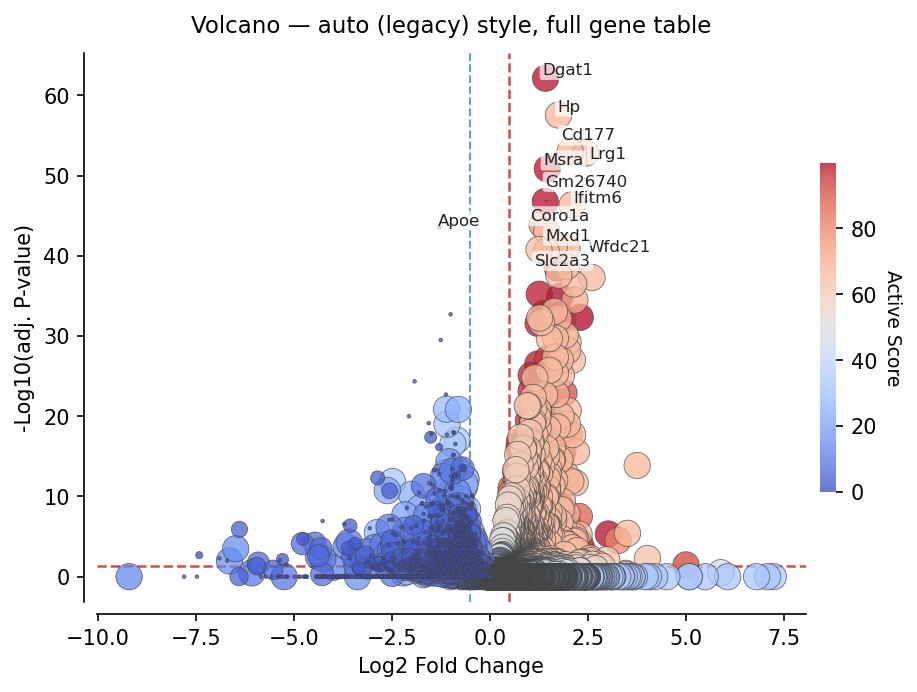

In [9]:
scat.pl.volcano_plot(
    all_results, style="auto", top_n=12, title="Volcano — auto (legacy) style, full gene table"
);


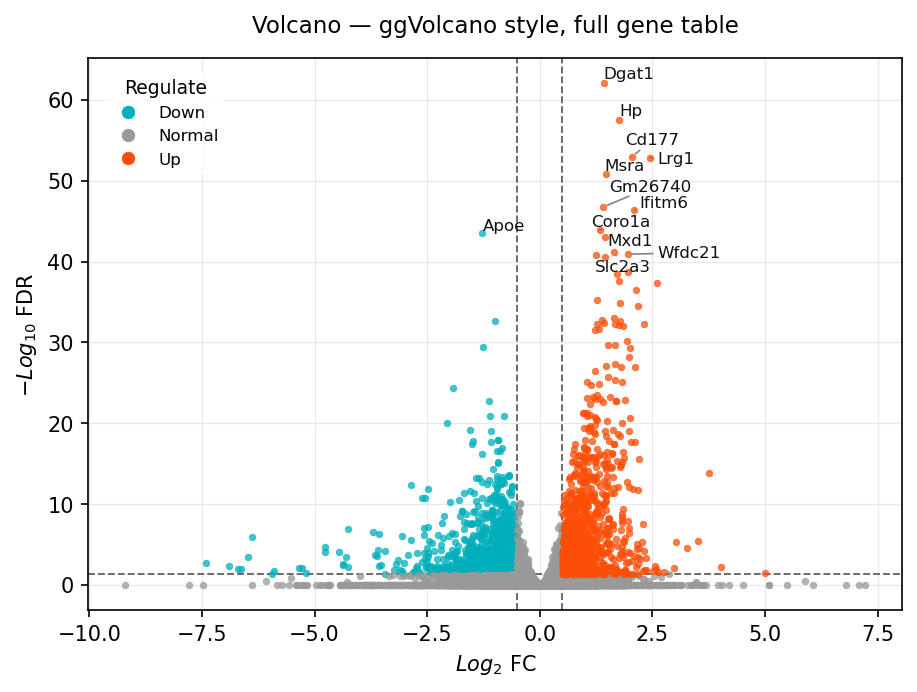

In [10]:
scat.pl.volcano_plot(
    all_results,
    style="ggvolcano",
    top_n=12,
    logfc_cutoff=0.5,
    pval_cutoff=0.05,
    title="Volcano — ggVolcano style, full gene table",
);


## ☄️ Comet plot


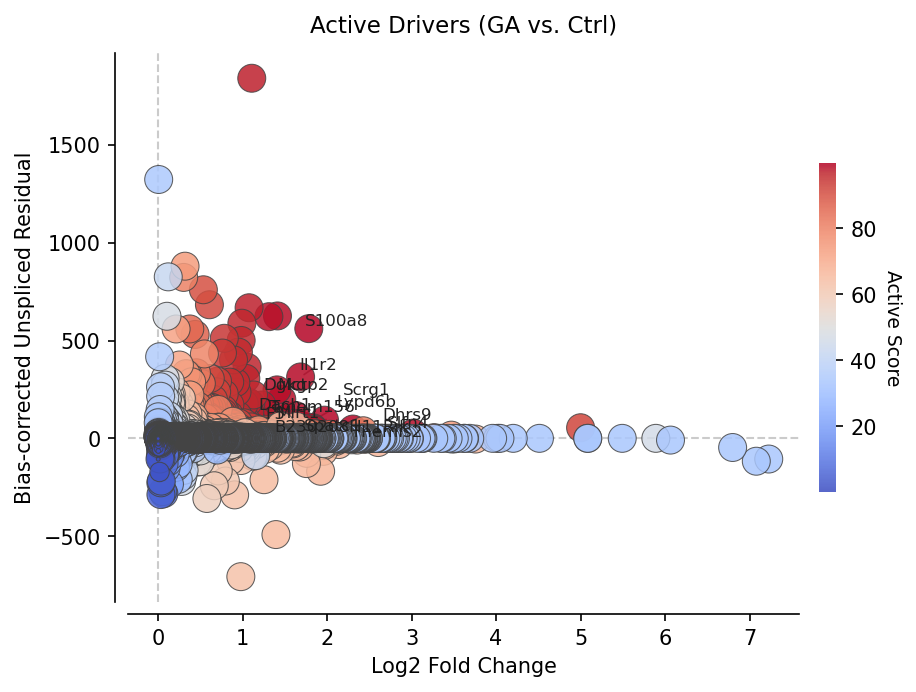

In [11]:
scat.pl.comet_plot(all_results, top_n=15, title="Active Drivers (GA vs. Ctrl)");


## 🧪 Functional enrichment


In [12]:
enrich_res = scat.run_enrichment(
    gene_list=candidates.index.tolist(),
    gene_sets="GO_Biological_Process",
    organism="mouse",
    adata=adata,
    pval_cutoff=0.05,
)
print(f"Significant GO Biological Process terms (p.adjust < 0.05): {len(enrich_res)}")
enrich_res.sort_values("p.adjust").head(10)[["Term", "Count", "pvalue", "p.adjust"]]


Significant GO Biological Process terms (p.adjust < 0.05): 251


,Term,Count,pvalue,p.adjust
0,myeloid leukocyte activation (GO:0002274),43,1.175680e-12,9.945079e-09
1,immune response-regulating cell surface recept...,46,1.875273e-10,7.729051e-07
2,leukocyte mediated immunity (GO:0002443),52,2.741122e-10,7.729051e-07
3,leukocyte degranulation (GO:0043299),21,4.762394e-10,1.007127e-06
4,mast cell activation (GO:0045576),20,7.594757e-10,1.284881e-06
5,myeloid leukocyte mediated immunity (GO:0002444),24,1.800214e-09,2.538002e-06
6,adaptive immune response (GO:0002250),53,5.122559e-09,6.190247e-06
7,immune response-activating cell surface recept...,40,1.887168e-08,1.995444e-05
8,leukocyte activation involved in immune respon...,38,3.351420e-08,3.149962e-05
10,cell activation involved in immune response (G...,38,4.852923e-08,3.725453e-05


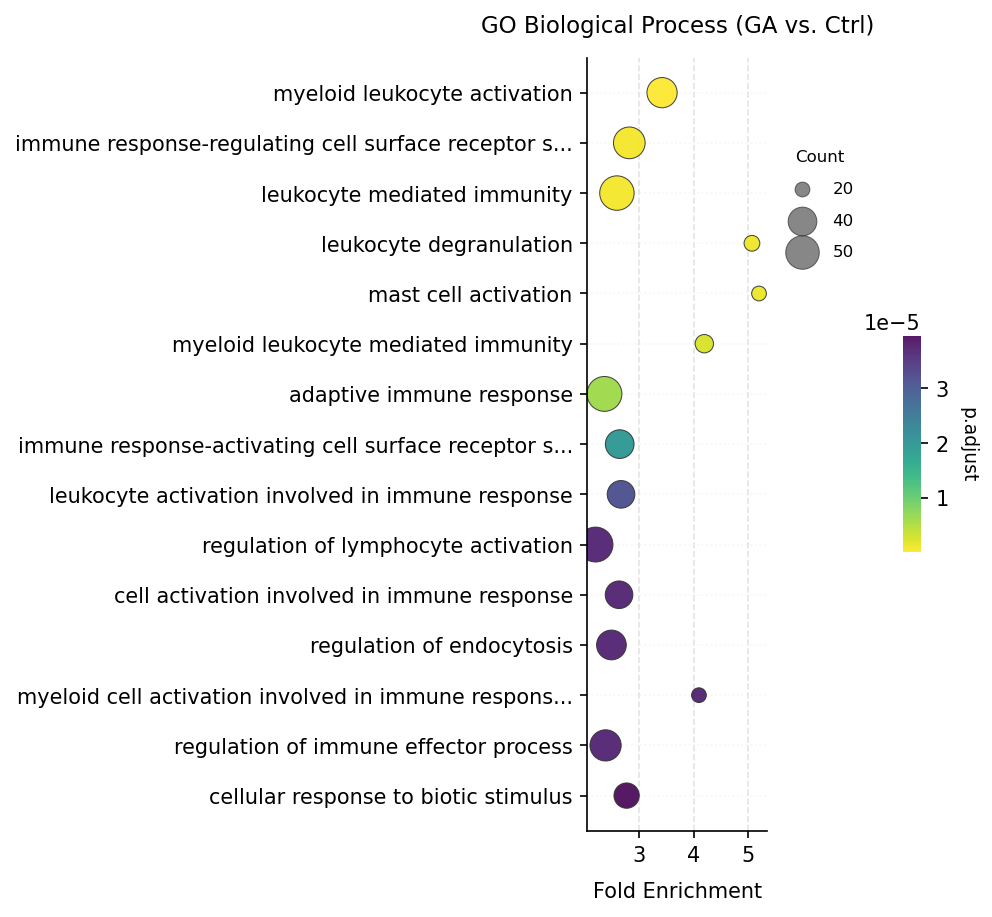

In [13]:
scat.pl.enrich_dotplot(enrich_res, top_n=15, title="GO Biological Process (GA vs. Ctrl)");


## 📊 Rank plot and marker heatmap


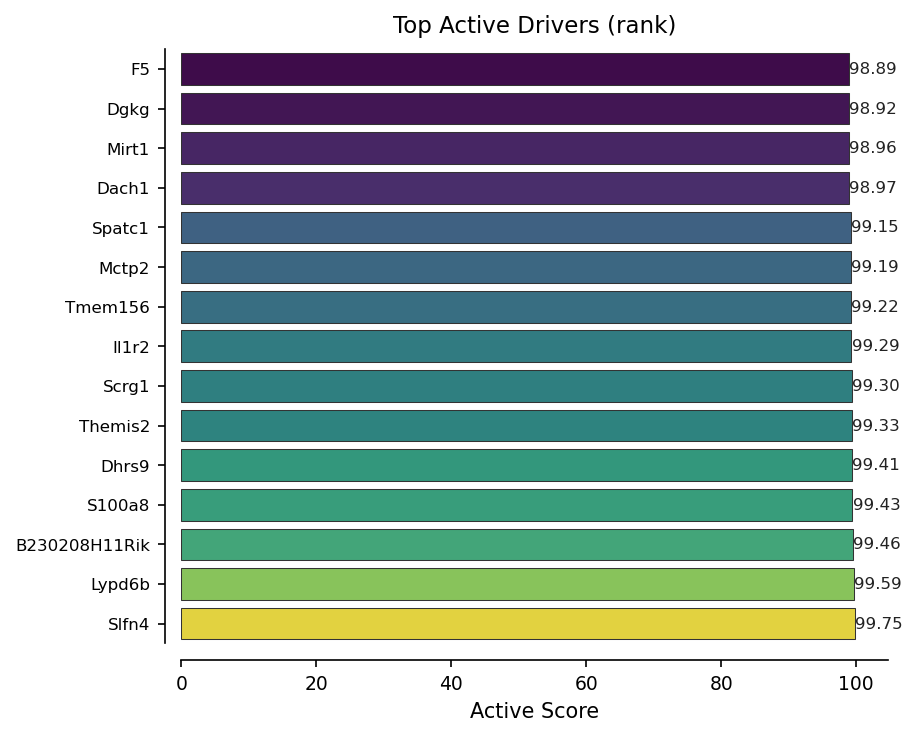

In [14]:
scat.pl.active_score_rankplot(all_results.sort_values("active_score", ascending=False), top_n=15);


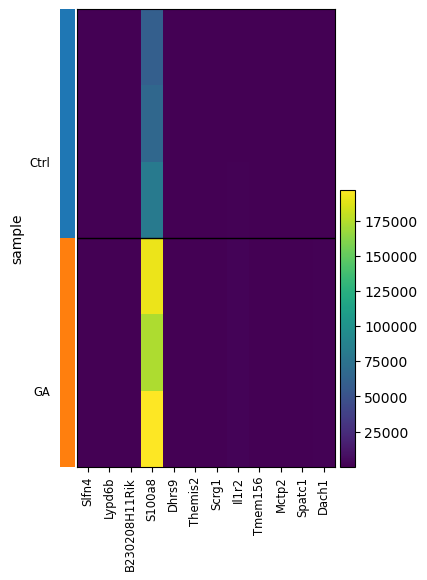

In [15]:
top_genes = all_results.sort_values("active_score", ascending=False).head(12).index.tolist()
scat.pl.active_genes_heatmap(adata_res, genes=top_genes, groupby="sample");


## ✅ Recap

Same `active_score` pipeline, same 3-vs-3 replicate structure, and the same
honest reporting conventions as {doc}`t_ec_active_transcription` — the
difference in how "convincing" the plots look here comes entirely from having
~330 cells per individual instead of ~10-40, not from a different analysis
path. Together the two notebooks make the core point concrete: for the
pseudobulk contrast, *more cells per sample* buys real power, but the number of
biological **samples** still governs what you can honestly claim. Report
`active_score` as a composite heuristic rank, and state your cutoffs — see
{doc}`../statistical_guidance`, {doc}`../user_guide/advanced`, and
{doc}`../references`.